In [1]:
import pandas as pd
monthly_complete = pd.read_csv("monthly_data.csv")
monthly_complete["Date"] = pd.to_datetime(monthly_complete["Date"])

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rolling_rf_forecast(monthly_complete, city_name):
    
    #Filter city
    city_df = monthly_complete[monthly_complete["City"] == city_name].copy()
    city_df.set_index("Date", inplace = True)

    df_ml = city_df.copy()

    for lag in [1, 2, 3, 6, 12]:
        df_ml[f"lag_{lag}"] = df_ml["Crime_Count"].shift(lag)
    
    #moving average of 3 months already exists in the original monthly dataframe
    df_ml["MA6"] = df_ml["Crime_Count"].rolling(6).mean()

    df_ml = df_ml.dropna()

    predictions = []
    actuals = []

    test_dates = df_ml["2024-01-01":].index

    for current_date in test_dates:

        #Getting the current training data
        train_data = df_ml.loc[:current_date - pd.DateOffset(months = 1)]

        x_train = train_data[[
            "lag_1", "lag_2", "lag_3",
            "lag_6", "lag_12", "MA3", "MA6"
        ]]

        y_train = train_data["Crime_Count"]

        rf = RandomForestRegressor(
            n_estimators = 300,
            max_depth = 5,
            random_state = 42
        )

        rf.fit(x_train, y_train)

        x_test = df_ml.loc[current_date,[
            "lag_1", "lag_2", "lag_3",
            "lag_6", "lag_12", "MA3", "MA6"
        ]].values.reshape(1, -1)

        prediction = rf.predict(x_test)[0]

        predictions.append(prediction)
        actuals.append(df_ml.loc[current_date, "Crime_Count"])
    
    mae = mean_absolute_error(actuals, predictions) #Mean absolute error
    rmse = np.sqrt(mean_squared_error(actuals, predictions)) #Root mean square error
    
    actuals_arr = np.array(actuals)
    pred_arr = np.array(predictions)

    mape = np.mean(np.abs((actuals_arr - pred_arr) / actuals_arr)) * 100 #Mean Absolute Percentage Error

    return {
        "City": city_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Predictions": predictions,
        "Actuals": actuals,
        "Dates": test_dates
    }

In [3]:
result_delhi = rolling_rf_forecast(monthly_complete, "Delhi")
print("MAE:", result_delhi["MAE"])
print("RMSE:", result_delhi["RMSE"])

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

MAE: 4.751483832181336
RMSE: 7.09238056824079


d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [4]:
all_results = []

for city in monthly_complete["City"].unique():
    city_result = rolling_rf_forecast(monthly_complete, city)
    all_results.append(city_result)

performance_df = pd.DataFrame(all_results)[["City", "MAE", "RMSE", "MAPE"]]
performance_df.sort_values("MAE", inplace = True)
performance_df.set_index("City", inplace = True)

print(performance_df)

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

                    MAE      RMSE        MAPE
City                                         
Surat          0.975577  1.310819    5.252085
Nashik         1.045566  1.297747   14.631270
Srinagar       1.249128  1.400255   23.114831
Kalyan         1.398664  1.729240   35.463517
Varanasi       1.493714  1.781662   26.084565
Indore         1.651449  1.999358   13.476167
Faridabad      1.741427  2.288713   24.828226
Agra           1.849292  2.124863   12.159966
Rajkot         1.855916  2.643611   54.810808
Kanpur         2.320211  2.702825   12.111785
Vasai          2.490804  2.920599  115.669818
Ghaziabad      2.491030  2.855316   25.728028
Nagpur         2.819065  3.520023   19.440381
Meerut         2.863328  3.471983   45.128338
Visakhapatnam  2.882097  3.374607   17.693963
Ludhiana       2.936947  3.843814   25.396163
Bhopal         3.065376  3.650264   24.177926
Jaipur         3.477866  4.215407   12.560051
Ahmedabad      3.842858  4.385013   12.980820
Chennai        3.881206  4.966429 

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [5]:
volatility_list = []

for city in monthly_complete["City"].unique():
    city_df = monthly_complete[monthly_complete["City"] == city]

    mean_crime = city_df["Crime_Count"].mean()
    std_crime = city_df["Crime_Count"].std()

    volatility = std_crime / mean_crime

    volatility_list.append({
        "City": city,
        "Volatility": volatility
    })

volatility_df = pd.DataFrame(volatility_list)

In [6]:
analysis_df = performance_df.merge(volatility_df, on = "City")
analysis_df.sort_values("Volatility", ascending=False)

,City,MAE,RMSE,MAPE,Volatility
13,Meerut,2.863328,3.471983,45.128338,0.427148
4,Varanasi,1.493714,1.781662,26.084565,0.426714
10,Vasai,2.490804,2.920599,115.669818,0.423411
8,Rajkot,1.855916,2.643611,54.810808,0.383028
2,Srinagar,1.249128,1.400255,23.114831,0.375495
3,Kalyan,1.398664,1.729240,35.463517,0.348758
6,Faridabad,1.741427,2.288713,24.828226,0.339292
1,Nashik,1.045566,1.297747,14.631270,0.302237
22,Patna,4.325076,5.489739,28.283954,0.289913
11,Ghaziabad,2.491030,2.855316,25.728028,0.286221


Correlation: 0.6061065137393215
P-value: 0.000492407183238464


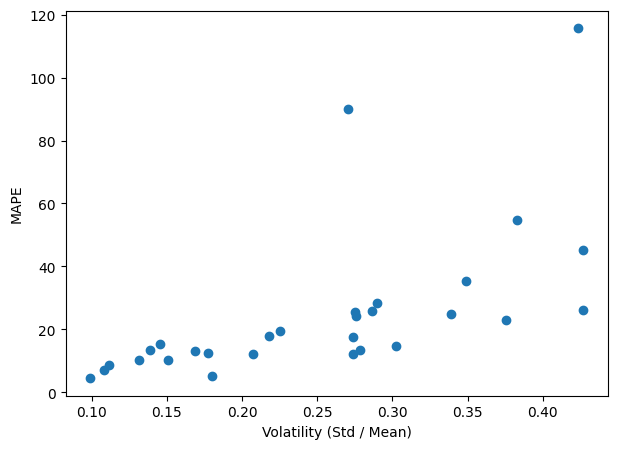

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

corr, p_value = pearsonr(analysis_df["Volatility"], analysis_df["MAPE"])
print("Correlation:", corr)
print("P-value:", p_value)

plt.figure(figsize=(7,5))
plt.scatter(analysis_df["Volatility"], analysis_df["MAPE"])
plt.xlabel("Volatility (Std / Mean)")
plt.ylabel("MAPE")
#plt.title("Volatility vs Forecast Error")
plt.show()


In [8]:
def forecase_future_12_months(monthly_complete, city_name):

    city_df = monthly_complete[monthly_complete["City"] == city_name].copy()
    city_df.set_index("Date", inplace = True)

    df_ml = city_df.copy()

    #Create lag and rolling features
    for lag in [1, 2, 3, 6, 12]:
        df_ml[f"lag_{lag}"] = df_ml["Crime_Count"].shift(lag)
    
    df_ml["MA6"] = df_ml["Crime_Count"].rolling(6).mean()

    df_ml = df_ml.dropna()

    #Train on full available data
    x = df_ml[[
        "lag_1", "lag_2", "lag_3",
        "lag_6", "lag_12", "MA3", "MA6"
    ]]
    y = df_ml["Crime_Count"]

    rf = RandomForestRegressor(
        n_estimators = 300,
        max_depth = 5,
        random_state = 42
    )

    rf.fit(x, y)

    future_predictions = []
    current_df = city_df.copy()

    for i in range(12):

        last_date = current_df.index[-1]
        next_date = last_date + pd.DateOffset(months = 1)

        #Create feature row for next month
        temp_df = current_df.copy()

        for lag in [1, 2, 3, 6, 12]:
            temp_df[f"lag_{lag}"] = temp_df["Crime_Count"].shift(lag)
        
        temp_df["MA3"] = temp_df["Crime_Count"].rolling(3).mean()
        temp_df["MA6"] = temp_df["Crime_Count"].rolling(6).mean()

        latest_features = temp_df.iloc[-1][[
            "lag_1", "lag_2", "lag_3",
            "lag_6", "lag_12", "MA3", "MA6"
        ]].values.reshape(1, -1)

        prediction = rf.predict(latest_features)[0]

        #Append prediction
        current_df.loc[next_date] = prediction
        future_predictions.append((next_date, prediction))
    
    future_df = pd.DataFrame(future_predictions, columns = ["Date", "Forecast"])

    return future_df
        

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

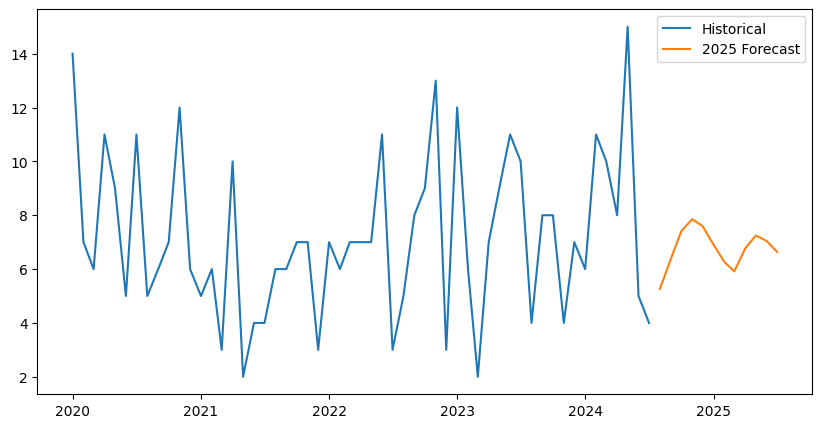

,Date,Forecast
0,2024-08-01,5.266890
1,2024-09-01,6.376060
2,2024-10-01,7.411639
3,2024-11-01,7.854062
4,2024-12-01,7.589354
5,2025-01-01,6.899512
6,2025-02-01,6.258211
7,2025-03-01,5.914383
8,2025-04-01,6.765831
9,2025-05-01,7.243237


In [15]:
future_delhi = forecase_future_12_months(monthly_complete, "Meerut")

city_df = monthly_complete[monthly_complete["City"] == "Meerut"]
city_df.set_index("Date", inplace = True)

plt.figure(figsize = (10, 5))
plt.plot(city_df["Crime_Count"], label = "Historical")
plt.plot(future_delhi["Date"], future_delhi["Forecast"], label = "2025 Forecast")
plt.legend()
#plt.title("Delhi Crime Forecast 2025")
plt.show()

future_delhi


In [10]:
"""
These are model-driven projections.
They assume:

No structural breaks

No policy shocks

No unexpected extreme events
"""

future_all = []

for city in monthly_complete["City"].unique():
    forecast_city = forecase_future_12_months(monthly_complete, city)
    forecast_city["City"] = city
    future_all.append(forecast_city)

future_projection_df = pd.concat(future_all)
future_projection_df.head()

d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\Python\Python Files\College Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

,Date,Forecast,City
0,2024-08-01,16.829704,Agra
1,2024-09-01,18.886293,Agra
2,2024-10-01,15.085812,Agra
3,2024-11-01,13.892392,Agra
4,2024-12-01,14.214515,Agra


In [11]:
performance_df = performance_df.reset_index()
monthly_complete.to_csv("monthly_data.csv", index = False)
performance_df.to_csv("performance.csv", index = False)
future_projection_df.to_csv("future_projection.csv", index = False)